# Arena Synchronization Verification

Diagnostic notebook to verify arena file consistency **before** applying OE synchronization.

Goal: Find the first bug appearance in bug_trajectory.csv (PC clock), locate the corresponding
frame in the left arena video (which shows the screen), and extract ±60 frames around that moment.

This verifies that:
1. bug_trajectory.csv timestamps are internally consistent
2. frames_timestamps align with the arena video files
3. We can locate events in the video before applying OE synchronization

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt

from eye_tracking_system_tools.preprocessing.arena_alignment import (
    arena_datetime_to_pc_ms,
    get_arena_alignment_constants,
    get_first_arena_frame_oe_ms,
    compute_pc_to_oe_shift_ms,
)
from eye_tracking_system_tools.preprocessing.BlockSync_class import BlockSync

%matplotlib inline

In [2]:
# Configuration
animal = "PV_208"
date = "2025_12_14"
block_num = "019"

base_path = Path(r"D:\sample_data_for_eye_repo")
block_path = base_path / animal / date / f"block_{block_num}"
arena_videos_dir = block_path / "arena_videos"

print(f"Block path: {block_path}")
print(f"Arena videos dir: {arena_videos_dir}")

Block path: D:\sample_data_for_eye_repo\PV_208\2025_12_14\block_019
Arena videos dir: D:\sample_data_for_eye_repo\PV_208\2025_12_14\block_019\arena_videos


## Step 1: Load bug trajectory and find first bug appearance

In [3]:
# Load bug_trajectory.csv (original, not aligned)
bug_traj_path = arena_videos_dir / "bug_trajectory.csv"
bug_df = pd.read_csv(bug_traj_path)

print(f"Bug trajectory: {len(bug_df)} rows")
print(f"Columns: {list(bug_df.columns)}")
print(f"\nFirst few rows:")
print(bug_df.head(10))

Bug trajectory: 65901 rows
Columns: ['Unnamed: 0', 'time', 'x', 'y']

First few rows:
   Unnamed: 0                              time           x           y
0           0  2025-12-14T12:30:40.651000+02:00  523.230362  309.651404
1           1  2025-12-14T12:30:40.667000+02:00  519.759110  312.090552
2           2  2025-12-14T12:30:40.683000+02:00  516.350939  314.617091
3           3  2025-12-14T12:30:40.699000+02:00  513.008047  317.229390
4           4  2025-12-14T12:30:40.715000+02:00  509.732592  319.925763
5           5  2025-12-14T12:30:40.731000+02:00  506.526689  322.704471
6           6  2025-12-14T12:30:40.747000+02:00  503.392405  325.563718
7           7  2025-12-14T12:30:40.763000+02:00  500.331764  328.501662
8           8  2025-12-14T12:30:40.779000+02:00  497.346742  331.516404
9           9  2025-12-14T12:30:40.795000+02:00  494.439264  334.606000


In [4]:
# Convert time column to PC-clock milliseconds
bug_df['time_pc_ms'] = arena_datetime_to_pc_ms(bug_df['time'])

# Find first bug appearance (first row with valid x, y)
valid_mask = bug_df['x'].notna() & bug_df['y'].notna()
first_bug_idx = bug_df[valid_mask].index[0] if valid_mask.any() else None

if first_bug_idx is None:
    raise ValueError("No valid bug positions found in bug_trajectory.csv")

first_bug_row = bug_df.loc[first_bug_idx]
first_bug_time_pc_ms = first_bug_row['time_pc_ms']
first_bug_time_iso = first_bug_row['time']

print(f"First bug appearance:")
print(f"  Index: {first_bug_idx}")
print(f"  Time (ISO): {first_bug_time_iso}")
print(f"  Time (PC ms): {first_bug_time_pc_ms:.2f} ms")
print(f"  Position: x={first_bug_row['x']:.2f}, y={first_bug_row['y']:.2f}")

First bug appearance:
  Index: 0
  Time (ISO): 2025-12-14T12:30:40.651000+02:00
  Time (PC ms): 1765708240651.00 ms
  Position: x=523.23, y=309.65


## Step 1b: Verify trials_data and screen_touches vs first bug

Check that the first trial start (earliest `trial_db_id`) and first bug datapoint are approximately aligned on the same PC-clock timeline. Also check first screen touch vs first bug and first trial.

In [5]:
# --- trials_data: first trial (lowest trial_db_id) vs first bug ---
trials_path = arena_videos_dir / "trials_data.csv"
if trials_path.exists():
    trials_df = pd.read_csv(trials_path)
    if "trial_db_id" in trials_df.columns and "start_time" in trials_df.columns:
        first_trial_row = trials_df.loc[trials_df["trial_db_id"].idxmin()]
        first_trial_start_pc_ms = arena_datetime_to_pc_ms(
            pd.Series([first_trial_row["start_time"]])
        ).iloc[0]
        distance_trial_to_bug_ms = first_bug_time_pc_ms - first_trial_start_pc_ms
        print("Trials_data verification (PC clock):")
        print(f"  First trial: trial_db_id={first_trial_row['trial_db_id']}, start_time={first_trial_row['start_time']}")
        print(f"  First trial start (PC ms): {first_trial_start_pc_ms:.2f}")
        print(f"  First bug time (PC ms):   {first_bug_time_pc_ms:.2f}")
        print(f"  Distance (first_bug - first_trial_start): {distance_trial_to_bug_ms:.2f} ms ({distance_trial_to_bug_ms/1000:.3f} s)")
        print("  (Positive = bug appears after trial start; expect small value, trial starts then bug appears.)")
    else:
        print("trials_data.csv missing 'trial_db_id' or 'start_time'; skipping trials verification.")
else:
    print("trials_data.csv not found; skipping trials verification.")

# --- screen_touches: first touch vs first bug (and first trial if available) ---
touches_path = arena_videos_dir / "screen_touches.csv"
if touches_path.exists():
    touches_df = pd.read_csv(touches_path)
    if "time" in touches_df.columns and len(touches_df) > 0:
        touch_pc_ms = arena_datetime_to_pc_ms(touches_df["time"])
        first_touch_pc_ms = touch_pc_ms.min()
        distance_touch_to_bug_ms = first_bug_time_pc_ms - first_touch_pc_ms
        print("\nScreen_touches verification (PC clock):")
        print(f"  First touch (PC ms): {first_touch_pc_ms:.2f}")
        print(f"  First bug time (PC ms): {first_bug_time_pc_ms:.2f}")
        print(f"  Distance (first_bug - first_touch): {distance_touch_to_bug_ms:.2f} ms ({distance_touch_to_bug_ms/1000:.3f} s)")
        if trials_path.exists() and "trial_db_id" in trials_df.columns and "start_time" in trials_df.columns:
            distance_touch_to_trial_ms = first_trial_start_pc_ms - first_touch_pc_ms
            print(f"  Distance (first_trial_start - first_touch): {distance_touch_to_trial_ms:.2f} ms (negative = touch before trial start)")
    else:
        print("screen_touches.csv missing 'time' or empty; skipping touches verification.")
else:
    print("screen_touches.csv not found; skipping touches verification.")

Trials_data verification (PC clock):
  First trial: trial_db_id=10097, start_time=2025-12-14T12:30:40.637000+02:00
  First trial start (PC ms): 1765708240637.00
  First bug time (PC ms):   1765708240651.00
  Distance (first_bug - first_trial_start): 14.00 ms (0.014 s)
  (Positive = bug appears after trial start; expect small value, trial starts then bug appears.)

Screen_touches verification (PC clock):
  First touch (PC ms): 1765708378493.00
  First bug time (PC ms): 1765708240651.00
  Distance (first_bug - first_touch): -137842.00 ms (-137.842 s)
  Distance (first_trial_start - first_touch): -137856.00 ms (negative = touch before trial start)


## Step 2: Load left arena video frame timestamps

In [6]:
# Find left arena camera frames_timestamps
frames_ts_dir = arena_videos_dir / "videos" / "frames_timestamps"
left_ts_files = list(frames_ts_dir.glob("*left*.csv"))

if not left_ts_files:
    # Try alternative naming
    left_ts_files = [f for f in frames_ts_dir.glob("*.csv") if "left" in f.stem.lower()]

if not left_ts_files:
    print("Available timestamp files:")
    for f in frames_ts_dir.glob("*.csv"):
        print(f"  {f.name}")
    raise FileNotFoundError("No left camera timestamp file found")

left_ts_path = left_ts_files[0]
print(f"Using left camera timestamps: {left_ts_path.name}")

# Load frames_timestamps (Unix seconds in column 1)
left_ts_df = pd.read_csv(left_ts_path, header=0)
print(f"\nLeft timestamp file shape: {left_ts_df.shape}")
print(f"Columns: {list(left_ts_df.columns)}")
print(f"\nFirst few rows:")
print(left_ts_df.head(10))

Using left camera timestamps: left_20251214T123030.csv

Left timestamp file shape: (107697, 2)
Columns: ['Unnamed: 0', '0']

First few rows:
   Unnamed: 0             0
0           0  1.765708e+09
1           1  1.765708e+09
2           2  1.765708e+09
3           3  1.765708e+09
4           4  1.765708e+09
5           5  1.765708e+09
6           6  1.765708e+09
7           7  1.765708e+09
8           8  1.765708e+09
9           9  1.765708e+09


In [7]:
# Convert frames_timestamps to PC-clock milliseconds
# Column 1 contains Unix seconds (frame 0 is row 0, column 1)
unix_s_col = left_ts_df.columns[1]  # Usually '0' or similar
left_ts_df['frame_idx'] = left_ts_df.iloc[:, 0].values  # Frame index
left_ts_df['unix_s'] = left_ts_df[unix_s_col].values
left_ts_df['pc_ms'] = left_ts_df['unix_s'] * 1000.0  # Convert to milliseconds

print(f"Frame timestamps converted to PC-clock milliseconds")
print(f"  Frame 0 PC time: {left_ts_df.iloc[0]['pc_ms']:.2f} ms")
print(f"  Frame {len(left_ts_df)-1} PC time: {left_ts_df.iloc[-1]['pc_ms']:.2f} ms")
print(f"  Total frames: {len(left_ts_df)}")
print(f"  Frame rate: ~{1000.0 / np.median(np.diff(left_ts_df['pc_ms'])):.2f} Hz")

Frame timestamps converted to PC-clock milliseconds
  Frame 0 PC time: 1765708230354.25 ms
  Frame 107696 PC time: 1765710067440.68 ms
  Total frames: 107697
  Frame rate: ~59.11 Hz


## Step 3: Find the frame corresponding to first bug appearance

In [8]:
# Find the frame closest to first bug appearance time
bug_time_pc_ms = first_bug_time_pc_ms
frame_times_pc_ms = left_ts_df['pc_ms'].values

# Find closest frame
diffs = np.abs(frame_times_pc_ms - bug_time_pc_ms)
closest_frame_idx = np.argmin(diffs)
closest_frame_time_pc_ms = frame_times_pc_ms[closest_frame_idx]
time_diff_ms = closest_frame_time_pc_ms - bug_time_pc_ms

print(f"First bug appearance:")
print(f"  Bug time (PC ms): {bug_time_pc_ms:.2f} ms")
print(f"  Closest frame: {closest_frame_idx}")
print(f"  Frame time (PC ms): {closest_frame_time_pc_ms:.2f} ms")
print(f"  Time difference: {time_diff_ms:.2f} ms ({time_diff_ms/1000:.3f} s)")

# Extract ±60 frames around the bug appearance
frames_before = 60
frames_after = 60
frame_start = max(0, closest_frame_idx - frames_before)
frame_end = min(len(left_ts_df), closest_frame_idx + frames_after + 1)

frame_range = left_ts_df.iloc[frame_start:frame_end].copy()
bug_frame_in_range = closest_frame_idx - frame_start

print(f"\nFrame range for extraction:")
print(f"  Start frame: {frame_start} (PC time: {frame_range.iloc[0]['pc_ms']:.2f} ms)")
print(f"  Bug frame (in range): {bug_frame_in_range} (absolute: {closest_frame_idx})")
print(f"  End frame: {frame_end-1} (PC time: {frame_range.iloc[-1]['pc_ms']:.2f} ms)")
print(f"  Total frames: {len(frame_range)} (should be {frames_before + frames_after + 1})")

First bug appearance:
  Bug time (PC ms): 1765708240651.00 ms
  Closest frame: 608
  Frame time (PC ms): 1765708240645.21 ms
  Time difference: -5.79 ms (-0.006 s)

Frame range for extraction:
  Start frame: 548 (PC time: 1765708239629.52 ms)
  Bug frame (in range): 60 (absolute: 608)
  End frame: 668 (PC time: 1765708241660.78 ms)
  Total frames: 121 (should be 121)


## Step 4: Locate video file and report time range

In [9]:
# Find left arena video file
videos_dir = arena_videos_dir / "videos"
left_video_files = list(videos_dir.glob("*left*.mp4"))

if not left_video_files:
    left_video_files = [f for f in videos_dir.glob("*.mp4") if "left" in f.stem.lower()]

if not left_video_files:
    print("Available video files:")
    for f in videos_dir.glob("*.mp4"):
        print(f"  {f.name}")
    raise FileNotFoundError("No left arena video file found")

left_video_path = left_video_files[0]
print(f"Left arena video: {left_video_path.name}")

# Open video to get frame rate and total frames
cap = cv2.VideoCapture(str(left_video_path))
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {left_video_path}")

video_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"\nVideo properties:")
print(f"  FPS: {video_fps:.2f}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {total_frames / video_fps:.2f} s")

# Verify frame range is within video
if frame_end > total_frames:
    print(f"\nWARNING: Requested end frame {frame_end-1} exceeds video length {total_frames}")
    frame_end = total_frames
    frame_range = left_ts_df.iloc[frame_start:frame_end].copy()
    bug_frame_in_range = closest_frame_idx - frame_start

print(f"\nFrame range is within video bounds: ✓")

Left arena video: left_20251214T123030.mp4

Video properties:
  FPS: 58.82
  Total frames: 107697
  Duration: 1830.96 s

Frame range is within video bounds: ✓


## Step 5: Report time range in seconds (where to look in the video)

In [10]:
# Convert PC-clock milliseconds to relative seconds from video start
# Use the first frame timestamp as reference
first_frame_pc_ms = left_ts_df.iloc[0]['pc_ms']

# Time range in PC-clock milliseconds
range_start_pc_ms = frame_range.iloc[0]['pc_ms']
range_end_pc_ms = frame_range.iloc[-1]['pc_ms']
bug_time_pc_ms_rel = bug_time_pc_ms - first_frame_pc_ms
range_start_pc_ms_rel = range_start_pc_ms - first_frame_pc_ms
range_end_pc_ms_rel = range_end_pc_ms - first_frame_pc_ms

# Convert to seconds
bug_time_s = bug_time_pc_ms_rel / 1000.0
range_start_s = range_start_pc_ms_rel / 1000.0
range_end_s = range_end_pc_ms_rel / 1000.0

print("=" * 70)
print("VERIFICATION REPORT: First Bug Appearance")
print("=" * 70)
print(f"\nBug trajectory (PC clock):")
print(f"  First bug time (ISO): {first_bug_time_iso}")
print(f"  First bug time (PC ms): {first_bug_time_pc_ms:.2f} ms")
print(f"  First bug position: x={first_bug_row['x']:.2f}, y={first_bug_row['y']:.2f}")

print(f"\nLeft arena video (PC clock):")
print(f"  Video file: {left_video_path.name}")
print(f"  First frame PC time: {first_frame_pc_ms:.2f} ms")
print(f"  Closest frame to bug: frame {closest_frame_idx}")
print(f"  Frame time (PC ms): {closest_frame_time_pc_ms:.2f} ms")
print(f"  Time difference: {time_diff_ms:.2f} ms ({time_diff_ms/1000:.3f} s)")

print(f"\nTime range (±60 frames around bug):")
print(f"  Start: {range_start_s:.3f} s (relative to video start)")
print(f"  Bug: {bug_time_s:.3f} s (relative to video start)")
print(f"  End: {range_end_s:.3f} s (relative to video start)")
print(f"  Duration: {range_end_s - range_start_s:.3f} s")

print(f"\nFrame indices:")
print(f"  Start frame: {frame_start} (bug frame is at index {bug_frame_in_range} within this range)")
print(f"  End frame: {frame_end-1}")

print(f"\n" + "=" * 70)
print(f"SUMMARY: Look for the bug at ~{bug_time_s:.3f} s in the left arena video")
print(f"         Extract frames {frame_start} to {frame_end-1} (±60 frames around bug)")
print(f"         Time range: {range_start_s:.3f} s to {range_end_s:.3f} s")
print("=" * 70)

VERIFICATION REPORT: First Bug Appearance

Bug trajectory (PC clock):
  First bug time (ISO): 2025-12-14T12:30:40.651000+02:00
  First bug time (PC ms): 1765708240651.00 ms
  First bug position: x=523.23, y=309.65

Left arena video (PC clock):
  Video file: left_20251214T123030.mp4
  First frame PC time: 1765708230354.25 ms
  Closest frame to bug: frame 608
  Frame time (PC ms): 1765708240645.21 ms
  Time difference: -5.79 ms (-0.006 s)

Time range (±60 frames around bug):
  Start: 9.275 s (relative to video start)
  Bug: 10.297 s (relative to video start)
  End: 11.307 s (relative to video start)
  Duration: 2.031 s

Frame indices:
  Start frame: 548 (bug frame is at index 60 within this range)
  End frame: 668

SUMMARY: Look for the bug at ~10.297 s in the left arena video
         Extract frames 548 to 668 (±60 frames around bug)
         Time range: 9.275 s to 11.307 s


## Step 6: Extract and display frames (optional verification)

## Step 7: Synchronization Verification Test

Now we verify that our synchronization shift correctly maps between PC-clock and OE-clock:

1. Take the bug frame timestamp (PC-clock) and frame number we found
2. Apply the synchronization shift to convert PC-clock → OE-clock (ms_axis)
3. Use OE ms_axis to find the closest Arena_TTL frame
4. Compare: should get the same arena frame number

This proves the synchronization works correctly!

In [11]:
# Load block and compute synchronization constants
print("Loading block and computing synchronization constants...")
block = BlockSync(animal,date,block_num,base_path)
block.parse_open_ephys_events()

# Get alignment constants
align_constants = get_arena_alignment_constants(block, arena_videos_dir)

print(f"\nSynchronization constants:")
print(f"  First arena frame (OE clock): {align_constants['first_arena_frame_oe_ms']:.2f} ms")
print(f"  First arena frame (PC clock): {align_constants['first_arena_frame_pc_ms']:.2f} ms")
print(f"  Shift: {align_constants['shift_ms']:.2f} ms")
print(f"  Camera accuracy: {align_constants['camera_accuracy_ms']:.2f} ms")

Loading block and computing synchronization constants...
instantiated block number 019 at Path: D:\sample_data_for_eye_repo\PV_208\2025_12_14\block_019, new OE version
Found the sample rate for block 019 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_208\2025_12_14\block_019\oe_files\PV208_d5t2_2025-12-14_12-29-53\Record Node 106...

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode)
retrieving zertoh sample number for block 019
got it!
running parse_open_ephys_events...
block 019 has a parsed events file, reading...

Synchronization constants:
  First arena frame (OE clock): 15.40 ms
  First arena frame (PC clock): 1765708230354.76 ms
  Shift: 1765708230339.36 ms
  Camera accuracy: 7.73 ms


In [12]:
# Step 1: We already have the bug frame in PC-clock
bug_frame_pc_ms = closest_frame_time_pc_ms  # Frame timestamp from frames_timestamps
bug_frame_number_pc = closest_frame_idx  # Frame number (0-indexed)

print(f"Bug frame (PC-clock world):")
print(f"  Frame number: {bug_frame_number_pc}")
print(f"  Frame timestamp (PC ms): {bug_frame_pc_ms:.2f} ms")

Bug frame (PC-clock world):
  Frame number: 608
  Frame timestamp (PC ms): 1765708240645.21 ms


In [13]:
# Step 2: Apply synchronization shift to convert PC-clock → OE-clock
shift_ms = align_constants['shift_ms']
bug_frame_oe_ms = bug_frame_pc_ms - shift_ms

print(f"Bug frame (OE-clock world):")
print(f"  Frame timestamp (OE ms / ms_axis): {bug_frame_oe_ms:.2f} ms")
print(f"  Applied shift: {shift_ms:.2f} ms")

Bug frame (OE-clock world):
  Frame timestamp (OE ms / ms_axis): 10305.85 ms
  Applied shift: 1765708230339.36 ms


In [14]:
# Step 3: Convert OE ms_axis to OE sample number
fs = block.sample_rate
bug_frame_oe_sample = bug_frame_oe_ms * (fs / 1000.0)

print(f"Bug frame (OE sample space):")
print(f"  OE sample: {bug_frame_oe_sample:.0f}")
print(f"  Sample rate: {fs:.2f} Hz")

Bug frame (OE sample space):
  OE sample: 206117
  Sample rate: 20000.00 Hz


In [15]:
# Step 4: Find the closest Arena_TTL frame using OE sample
arena_ttl_samples = block.oe_events['Arena_TTL'].dropna().astype(np.int64).values

# Find closest Arena_TTL sample
diffs_oe = np.abs(arena_ttl_samples - bug_frame_oe_sample)
closest_arena_ttl_idx = np.argmin(diffs_oe)
closest_arena_ttl_sample = arena_ttl_samples[closest_arena_ttl_idx]
time_diff_samples = closest_arena_ttl_sample - bug_frame_oe_sample
time_diff_ms_oe = time_diff_samples / (fs / 1000.0)

# The frame number is the index in the Arena_TTL array
bug_frame_number_oe = closest_arena_ttl_idx

print(f"Closest Arena_TTL frame (OE-clock world):")
print(f"  Arena_TTL sample: {closest_arena_ttl_sample}")
print(f"  Frame number (OE): {bug_frame_number_oe}")
print(f"  Time difference: {time_diff_samples:.0f} samples ({time_diff_ms_oe:.2f} ms)")

Closest Arena_TTL frame (OE-clock world):
  Arena_TTL sample: 206127
  Frame number (OE): 608
  Time difference: 10 samples (0.50 ms)


In [16]:
# Step 5: Compare frame numbers
frame_match = (bug_frame_number_pc == bug_frame_number_oe)
frame_diff = abs(bug_frame_number_pc - bug_frame_number_oe)

print("=" * 70)
print("SYNCHRONIZATION VERIFICATION RESULT")
print("=" * 70)
print(f"\nPC-clock world:")
print(f"  Frame number: {bug_frame_number_pc}")
print(f"  Frame timestamp: {bug_frame_pc_ms:.2f} ms (PC clock)")

print(f"\nOE-clock world:")
print(f"  Frame number: {bug_frame_number_oe}")
print(f"  Frame timestamp: {bug_frame_oe_ms:.2f} ms (OE ms_axis)")

print(f"\nComparison:")
print(f"  Frame numbers match: {frame_match}")
if not frame_match:
    print(f"  Frame difference: {frame_diff} frames")
    print(f"  Time difference: {frame_diff * (1000.0 / 60.0):.2f} ms (at ~60 Hz)")

print(f"\n" + "=" * 70)
if frame_match:
    print("✓ SUCCESS: Synchronization verified! Frame numbers match.")
elif frame_diff <= 1:
    print(f"✓ SUCCESS: Synchronization verified! Frame numbers differ by {frame_diff} (within tolerance).")
else:
    print(f"✗ WARNING: Frame numbers differ by {frame_diff}. Check synchronization logic.")
print("=" * 70)

SYNCHRONIZATION VERIFICATION RESULT

PC-clock world:
  Frame number: 608
  Frame timestamp: 1765708240645.21 ms (PC clock)

OE-clock world:
  Frame number: 608
  Frame timestamp: 10305.85 ms (OE ms_axis)

Comparison:
  Frame numbers match: True

✓ SUCCESS: Synchronization verified! Frame numbers match.


Extracted 5 sample frames


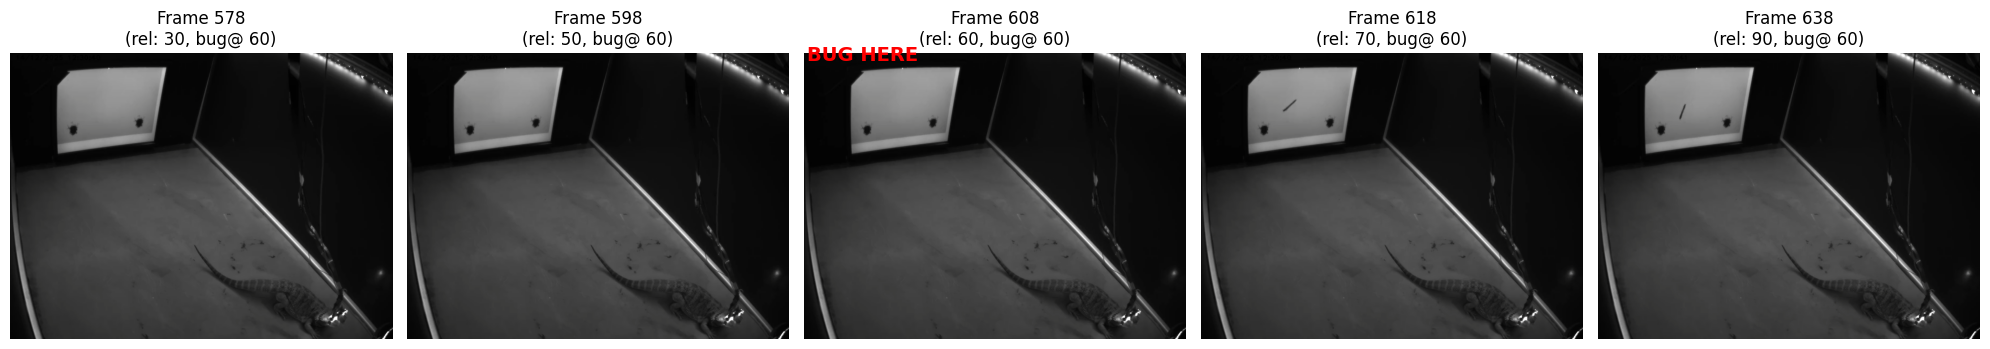

In [17]:
# Extract a few sample frames around the bug appearance for visual verification
sample_frames = [bug_frame_in_range - 30, bug_frame_in_range - 10, bug_frame_in_range, 
                 bug_frame_in_range + 10, bug_frame_in_range + 30]
sample_frames = [f for f in sample_frames if 0 <= f < len(frame_range)]

cap = cv2.VideoCapture(str(left_video_path))
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {left_video_path}")

extracted_frames = []
for rel_idx in sample_frames:
    abs_frame = frame_start + rel_idx
    cap.set(cv2.CAP_PROP_POS_FRAMES, abs_frame)
    ret, frame = cap.read()
    if ret:
        extracted_frames.append((rel_idx, abs_frame, frame))
    else:
        print(f"Warning: Could not read frame {abs_frame}")

cap.release()

if extracted_frames:
    print(f"Extracted {len(extracted_frames)} sample frames")
    
    # Display frames
    n_frames = len(extracted_frames)
    fig, axes = plt.subplots(1, n_frames, figsize=(4*n_frames, 4))
    if n_frames == 1:
        axes = [axes]
    
    for i, (rel_idx, abs_frame, frame) in enumerate(extracted_frames):
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {abs_frame}\n(rel: {rel_idx}, bug@ {bug_frame_in_range})")
        axes[i].axis('off')
        if rel_idx == bug_frame_in_range:
            axes[i].text(10, 30, "BUG HERE", color='red', fontsize=14, weight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No frames extracted")

## Step 8: Write ms_axis-aligned arena CSVs to analysis folder

After verification (Steps 1–7 and 1b), write the aligned tables to `analysis/arena_events_ms/` with suffixed filenames. Only verified streams are written (bug_trajectory, trials_data, screen_touches). Requires block loaded (Step 7).

In [18]:
# Write ms_axis-aligned CSVs to block's analysis/arena_events_ms/ (run Step 7 first to load block)
from eye_tracking_system_tools.preprocessing.arena_alignment import write_arena_events_ms_axis

written = write_arena_events_ms_axis(block, arena_videos_dir)
for p in written:
    print(f"  {p.relative_to(block_path)}")

[Arena alignment] Wrote 3 ms_axis-aligned CSV(s) to D:\sample_data_for_eye_repo\PV_208\2025_12_14\block_019\analysis\arena_events_ms
  analysis\arena_events_ms\bug_trajectory_ms_axis.csv
  analysis\arena_events_ms\trials_data_ms_axis.csv
  analysis\arena_events_ms\screen_touches_ms_axis.csv
